# Target benchmark preparation

## Importing libraries

In [1]:
import collections
import typing
import json
import pathlib
import zipfile

import tqdm
import PIL.Image
import IPython.display

## Uploading data

In [2]:
links: list[str] = [
    'https://ds4sd-public-artifacts.s3.eu-de.cloud-object-storage.appdomain.cloud/datasets/synthtabnet_public/v2.0.0/fintabnet.zip',
    'https://ds4sd-public-artifacts.s3.eu-de.cloud-object-storage.appdomain.cloud/datasets/synthtabnet_public/v2.0.0/marketing.zip',
    'https://ds4sd-public-artifacts.s3.eu-de.cloud-object-storage.appdomain.cloud/datasets/synthtabnet_public/v2.0.0/pubtabnet.zip',
    'https://ds4sd-public-artifacts.s3.eu-de.cloud-object-storage.appdomain.cloud/datasets/synthtabnet_public/v2.0.0/sparse.zip',
]
# Test work
# links: list[str] = [
#     'https://ds4sd-public-artifacts.s3.eu-de.cloud-object-storage.appdomain.cloud/datasets/synthtabnet_public/samples.zip',
# ]

In [3]:
class DataSet(typing.NamedTuple):
  link: str
  name: str
  zip_fn: str
  path_to_data: pathlib.Path
  path_to_ann: pathlib.Path

In [4]:
datasets: list[DataSet] = []
for link in links:
  zip_fn = link.split('/')[-1]
  name = zip_fn.split('.')[0]
  path_to_data = pathlib.Path(name) / 'images' / 'test'
  path_to_ann = pathlib.Path(name) / 'synthetic_data.jsonl'
  datasets.append(DataSet(
      link=link,
      name=name,
      zip_fn=zip_fn,
      path_to_data=path_to_data,
      path_to_ann=path_to_ann,
  ))

In [5]:
for dataset in datasets:
  print(f' {dataset.name} '.center(60, '='))
  print('Downloading...')
  !wget '{dataset.link}'
  print('Extracting...')
  zipfile.ZipFile(dataset.zip_fn, 'r').extractall('.')
  !rm '{dataset.zip_fn}'
  print('Done\n')

======================== fintabnet =========================
Downloading...
--2026-03-31 12:58:34--  https://ds4sd-public-artifacts.s3.eu-de.cloud-object-storage.appdomain.cloud/datasets/synthtabnet_public/v2.0.0/fintabnet.zip
Resolving ds4sd-public-artifacts.s3.eu-de.cloud-object-storage.appdomain.cloud (ds4sd-public-artifacts.s3.eu-de.cloud-object-storage.appdomain.cloud)... 158.177.118.101
Connecting to ds4sd-public-artifacts.s3.eu-de.cloud-object-storage.appdomain.cloud (ds4sd-public-artifacts.s3.eu-de.cloud-object-storage.appdomain.cloud)|158.177.118.101|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10806683504 (10G) [application/zip]
Saving to: ‘fintabnet.zip’

fintabnet.zip       100%[===================>]  10.06G  20.2MB/s    in 8m 49s  

2026-03-31 13:07:25 (19.5 MB/s) - ‘fintabnet.zip’ saved [10806683504/10806683504]

Extracting...
Done

======================== marketing =========================
Downloading...
--2026-03-31 13:11:01--  https://ds4

## Extracting images for a benchmark

In [6]:
test_images: dict[str, list[pathlib.Path]] = {}
for dataset in datasets:
  test_images[dataset.name] = sorted(dataset.path_to_data.iterdir())[:250]

In [7]:
for key in test_images:
  print(f' {key} '.center(50, '='))
  for path_to_img in test_images[key][:5]:
    print(path_to_img.stem)

  print()

=================== fintabnet ====================
image_000029_1634629328.565314
image_000044_1634629328.589694
image_000049_1634629328.598731
image_000053_1634629328.604574
image_000118_1634629347.784341

=================== marketing ====================
image_000001_1634629424.099311
image_000005_1634629424.113143
image_000014_1634629424.151227
image_000017_1634629424.172616
image_000030_1634629424.203423

=================== pubtabnet ====================
image_000000_1634629104.262938
image_000002_1634629104.270788
image_000016_1634629104.294217
image_000023_1634629104.305481
image_000032_1634629104.317631

===================== sparse =====================
image_000015_1634629370.562619
image_000017_1634629370.564773
image_000019_1634629370.565799
image_000032_1634629370.584401
image_000045_1634629370.600185



In [8]:
all_test_images: list[pathlib.Path] = []
for values in test_images.values():
  all_test_images.extend(values)

all_test_images.sort(
    key=lambda path_to_img: path_to_img.name,
)

## Rotation-Based Benchmark Construction

In [9]:
root_path_dataset = pathlib.Path('dataset')

In [10]:
path_to_imgs: dict[str, list[pathlib.Path]] = collections.defaultdict(list)

In [11]:
path_category_img = root_path_dataset / 'images'
path_category_img.mkdir(parents=True, exist_ok=True)
for ind, path_to_img  in enumerate(all_test_images):
    image = PIL.Image.open(path_to_img)
    image = image.rotate(360 - ind % 4 * 90, expand=True)
    image.save(path_category_img / path_to_img.name)
    path_to_imgs[path_to_img.parent.parent.parent.stem].append(
        path_category_img / path_to_img.name)

## Ground-Truth Table Representation

In [12]:
def format_html(ann: dict) -> str:
    r"""
    Formats annotations in html code
    """
    cells = ann["html"]["cells"]
    tokens = ann["html"]["structure"]["tokens"]
    table = []
    cell_idx = 0
    for token in tokens:
        if token.startswith("<td"):
            cell = cells[cell_idx]
            content = "".join(cell["tokens"])
            cell_idx += 1
        if token == "</td>":
            table.append(content)
        table.append(token)
    table_str = "".join(table)

    html_code = """<html>
    <head>
    <meta charset="UTF-8">
    <style>
    table, th, td {
      border: 1px solid black;
      font-size: 10px;
    }
    </style>
    </head>
    <body>
    <table frame="hsides" rules="groups" width="100%%">
    %s
    </table>
    </body>
    </html>""" % "".join(table_str)
    return html_code

In [13]:
img_to_html: dict[str, dict] = {}
for dataset in datasets:
  image_names: set[str] = [path_to_img.name for path_to_img in path_to_imgs[dataset.name]]
  with open(dataset.path_to_ann) as file:
    for _ in tqdm.tqdm(range(150_000)):
      ann_str = file.readline().replace(', ]', ']')
      ann = json.loads(ann_str)
      if ann['filename'] in image_names:
        img_to_html[ann['filename']] = format_html(ann)

with open(
  root_path_dataset / 'synthetic_data.json',
  'w',
  encoding='UTF-8',
) as file:
  json.dump(img_to_html, file)

100%|██████████| 150000/150000 [01:33<00:00, 1612.62it/s]


In [14]:
len(img_to_html)

1000

In [15]:
with open(
  root_path_dataset / 'synthetic_data.json',
  'r',
  encoding='UTF-8',
) as file:
  print(len(json.load(file)))

1000


Let's check the transformations.

In [16]:
img_dataset = root_path_dataset / 'images'

================================ image_000000_1634629104.262938.png ================================

Image table:



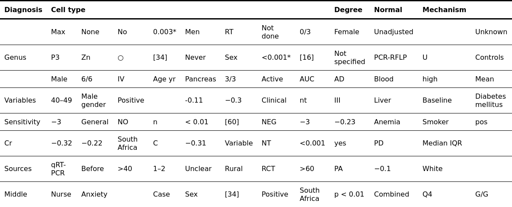


HTML code:




================================ image_000001_1634629424.099311.png ================================

Image table:



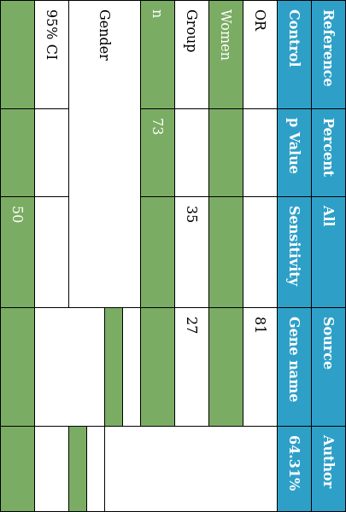


HTML code:




================================ image_000002_1634629104.270788.png ================================

Image table:



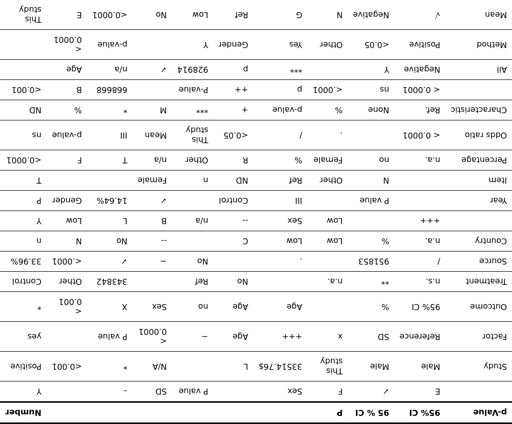


HTML code:



In [17]:
for path_to_img in sorted(img_dataset.iterdir())[:3]:
  print(f' {path_to_img.name} '.center(100, '='))
  print('\nImage table:\n')
  IPython.display.display(IPython.display.Image(filename=path_to_img))
  print('\nHTML code:\n')
  IPython.display.display(IPython.display.HTML(img_to_html[path_to_img.name]))
  print()

In [18]:
%%capture
!zip -r '{root_path_dataset.name}.zip' '{root_path_dataset.name}'/

As a result, the final dataset for the benchmark was generated.